In [35]:
import pandas as pd

In [36]:
df=pd.read_csv('Stock_Price_Data_[3921] (1).csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   str    
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 542.0 KB


In [38]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [39]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9909 entries, 1980-12-12 to 2020-04-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       9909 non-null   float64
 1   High       9909 non-null   float64
 2   Low        9909 non-null   float64
 3   Close      9909 non-null   float64
 4   Adj Close  9909 non-null   float64
 5   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 541.9 KB


In [40]:
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,9909.0,3.260685e+01,5.841576e+01,0.198661,1.071429e+00,1.729286e+00,3.580000e+01,3.247400e+02
High,9909.0,3.293608e+01,5.900158e+01,0.198661,1.089286e+00,1.758929e+00,3.626571e+01,3.278500e+02
Low,9909.0,3.227756e+01,5.788304e+01,0.196429,1.048571e+00,1.696429e+00,3.532857e+01,3.233500e+02
Close,9909.0,3.261803e+01,5.847190e+01,0.196429,1.071429e+00,1.732143e+00,3.576143e+01,3.272000e+02
Adj Close,9909.0,3.057657e+01,5.674627e+01,0.155638,9.176431e-01,1.466154e+00,3.104237e+01,3.272000e+02
Volume,9909.0,8.582916e+07,8.597195e+07,347200.000000,3.304230e+07,5.766490e+07,1.069992e+08,1.855410e+09


In [42]:
df.shape

(9909, 6)

In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

In [44]:
import numpy as np
X = []
y = []

sequence_length = 60

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i, 3])   # Close price index

X = np.array(X)
y = np.array(y)

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

model_lstm = Sequential()

model_lstm.add(LSTM(units=64,
                    return_sequences=True,
                    input_shape=(X_train.shape[1], X_train.shape[2])))

model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(units=64))

model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

/workspaces/Artificial-Intelligence-and-neural-network/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [46]:
model_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [51]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - loss: 2.1537e-05 - val_loss: 4.9969e-04
Epoch 2/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 2.0415e-05 - val_loss: 4.6640e-04
Epoch 3/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - loss: 1.9317e-05 - val_loss: 6.7329e-04
Epoch 4/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 1.9043e-05 - val_loss: 0.0012
Epoch 5/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - loss: 1.9614e-05 - val_loss: 6.7446e-04
Epoch 6/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - loss: 1.9424e-05 - val_loss: 3.6707e-04
Epoch 7/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 2.1697e-05 - val_loss: 9.6409e-04
Epoch 8/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - loss: 2.1078e-05 - val_loss: 3.6286e-04
Epoch 9/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 2.7230e-05 - val_loss: 0.0014
Epoch 10/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - loss: 1.6033e-05 - val_loss: 3.3260e-04
Epoch 11/100
247/247 ━━━━━━━━━━━━━━━━

In [52]:
from tensorflow.keras.layers import GRU

model_gru = Sequential()

model_gru.add(GRU(units=64,
                  return_sequences=True,
                  input_shape=(X_train.shape[1], X_train.shape[2])))

model_gru.add(Dropout(0.2))

model_gru.add(GRU(units=64))

model_gru.add(Dropout(0.2))

model_gru.add(Dense(1))

In [53]:
model_gru.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - loss: 8.8135e-05 - val_loss: 3.3755e-04
Epoch 2/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - loss: 3.3434e-05 - val_loss: 1.3118e-04
Epoch 3/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - loss: 2.6692e-05 - val_loss: 1.4222e-04
Epoch 4/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - loss: 2.4430e-05 - val_loss: 1.8237e-04
Epoch 5/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - loss: 2.1404e-05 - val_loss: 1.6769e-04
Epoch 6/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - loss: 2.4124e-05 - val_loss: 7.2824e-04
Epoch 7/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - loss: 3.0013e-05 - val_loss: 0.0011
Epoch 8/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - loss: 2.3389e-05 - val_loss: 0.0011
Epoch 9/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - loss: 2.5599e-05 - val_loss: 3.0092e-04
Epoch 10/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - loss: 2.0739e-05 - val_loss: 0.0021
Epoch 11/100
247/247 ━━━━━━━━━━━━━━━━━━━━

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# =========================
# LSTM Predictions
# =========================

lstm_predictions = model_lstm.predict(X_test)

# Calculate Metrics
lstm_mse = mean_squared_error(y_test, lstm_predictions)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae = mean_absolute_error(y_test, lstm_predictions)

print("LSTM Results")
print("MSE :", lstm_mse)
print("RMSE:", lstm_rmse)
print("MAE :", lstm_mae)


# =========================
# GRU Predictions
# =========================

gru_predictions = model_gru.predict(X_test)

# Calculate Metrics
gru_mse = mean_squared_error(y_test, gru_predictions)
gru_rmse = np.sqrt(gru_mse)
gru_mae = mean_absolute_error(y_test, gru_predictions)

print("\nGRU Results")
print("MSE :", gru_mse)
print("RMSE:", gru_rmse)
print("MAE :", gru_mae)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
LSTM Results
MSE : 0.00033259828048940376
RMSE: 0.018237277222474955
MAE : 0.01109655948518768
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

GRU Results
MSE : 0.00011644321027069415
RMSE: 0.010790885518375874
MAE : 0.0067131798978612815


In [55]:
import numpy as np

# 1. Create an empty grid of zeros matching the shape your scaler expects (1970 rows, 6 columns)
dummy_lstm = np.zeros((len(raw_predictions), 6))

# 2. Put your predictions into the correct column slot
# If your target was the FIRST column of your dataset, use this line:
dummy_lstm[:, 0] = raw_predictions.flatten()

# (OR: If your target was the LAST column of your dataset, uncomment the line below instead)
# dummy_lstm[:, -1] = raw_predictions.flatten()

# 3. Inverse transform the entire 6-column matrix
inverse_dummy_lstm = scaler.inverse_transform(dummy_lstm)

# 4. Extract just your prediction column back out!
predicted_prices_lstm = inverse_dummy_lstm[:, 0] # Change 0 to -1 if it was the last column

# 5. Do the exact same 5 steps for your y_test targets
dummy_actual = np.zeros((len(y_test), 6))
dummy_actual[:, 0] = y_test.flatten() # Change 0 to -1 if it was the last column
actual_prices = scaler.inverse_transform(dummy_actual)[:, 0]

In [56]:
import numpy as np

# 1. Generate the raw predictions from your trained GRU model
raw_predictions_gru = model_gru.predict(X_test)

# 2. Create an empty 6-column grid for the GRU predictions
dummy_gru = np.zeros((len(raw_predictions_gru), 6))

# 3. Place your GRU predictions into the target column slot
# (Match the index 0 or -1 to whatever you used for the LSTM step)
dummy_gru[:, 0] = raw_predictions_gru.flatten()

# 4. Inverse transform the matrix and extract the GRU price column
inverse_dummy_gru = scaler.inverse_transform(dummy_gru)
predicted_prices_gru = inverse_dummy_gru[:, 0] 
print("GRU predictions successfully converted back to original prices!")

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
GRU predictions successfully converted back to original prices!


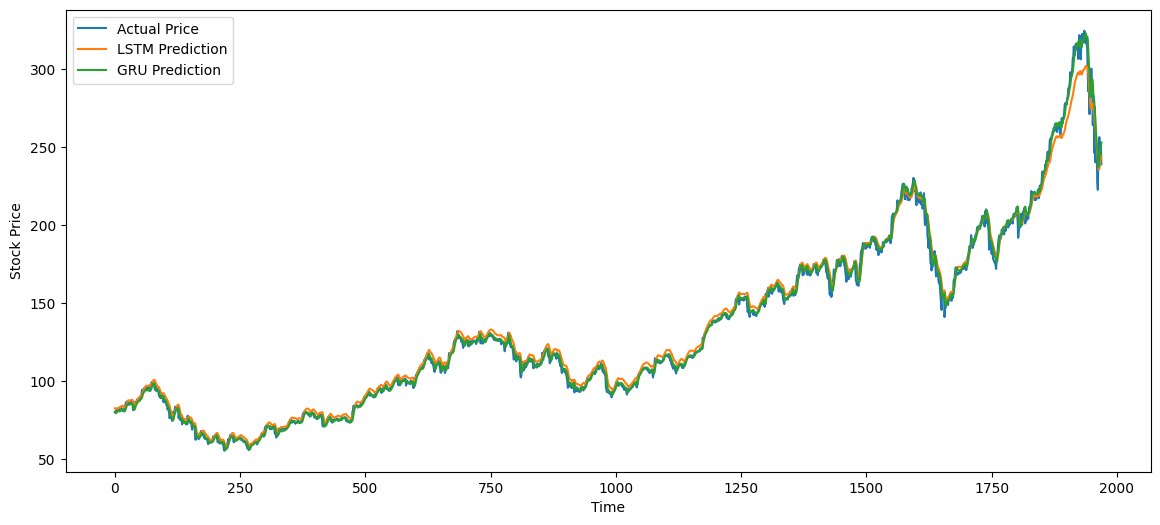

In [57]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices_lstm, label='LSTM Prediction')
plt.plot(predicted_prices_gru, label='GRU Prediction')

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

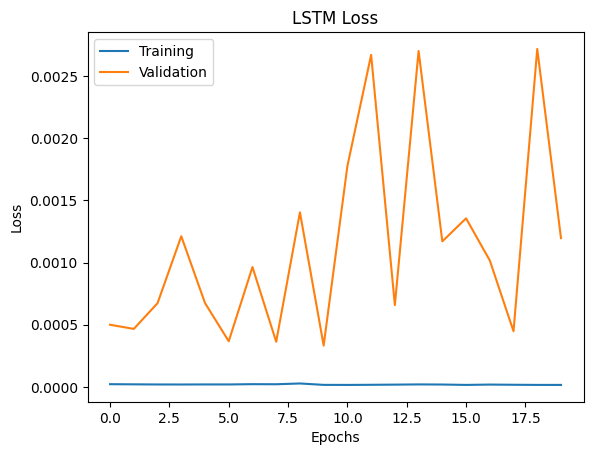

In [58]:
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])

plt.title('LSTM Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.show()

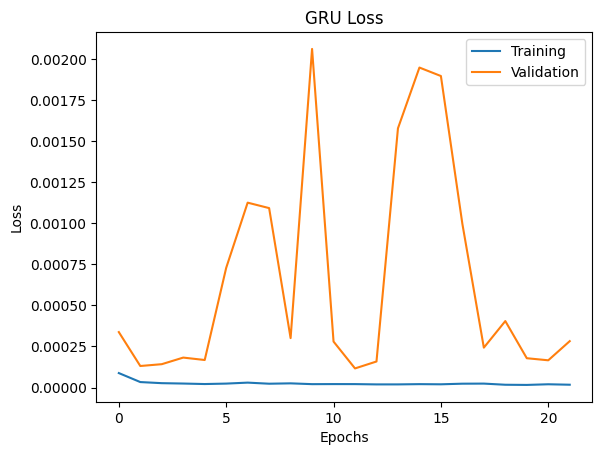

In [59]:
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])

plt.title('GRU Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])
plt.show()